In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('/content/drive/MyDrive/CommentToxicity/train.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (159571, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [5]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("Label counts:")
print(df[labels].sum())

print("\nLabel percentages:")
print((df[labels].sum() / len(df) * 100).round(2))

Label counts:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

Label percentages:
toxic            9.58
severe_toxic     1.00
obscene          5.29
threat           0.30
insult           4.94
identity_hate    0.88
dtype: float64


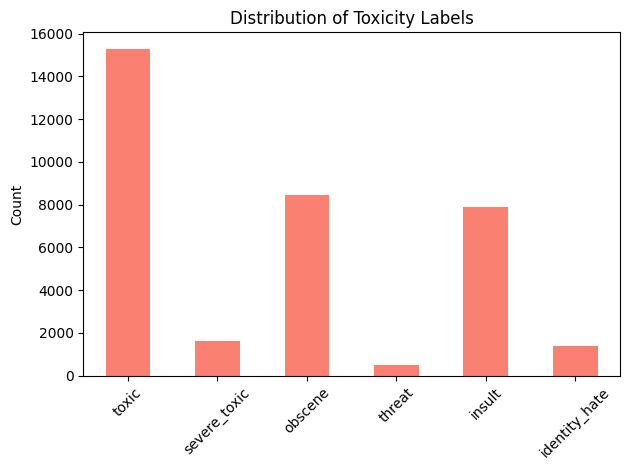

In [6]:
df[labels].sum().plot(kind='bar', color='salmon')
plt.title('Distribution of Toxicity Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import re
import string

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = text.strip()
    return text

# Test it
sample = "Hello!! <b>This</b> is a TEST comment 123 http://example.com"
print("Before:", sample)
print("After: ", clean_text(sample))

Before: Hello!! <b>This</b> is a TEST comment 123 http://example.com
After:  hello this is a test comment


In [8]:
df['clean_text'] = df['comment_text'].apply(clean_text)
print("Done! ✅")

# Compare before and after
print("\nOriginal:", df['comment_text'][0][:100])
print("Cleaned: ", df['clean_text'][0][:100])

Done! ✅

Original: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't 
Cleaned:  explanation
why the edits made under my username hardcore metallica fan were reverted they werent va


In [9]:
# Define how many unique words to keep (top 20000 most common)
MAX_WORDS = 20000
# Define max length of each comment (in words)
MAX_LEN = 200

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS)

# Learn the vocabulary from our cleaned comments
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences of numbers
sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("Vocabulary size:", len(tokenizer.word_index))
print("\nSample comment:", df['clean_text'][0][:50])
print("As numbers:     ", sequences[0][:15])

Vocabulary size: 226512

Sample comment: explanation
why the edits made under my username h
As numbers:      [639, 75, 1, 122, 126, 171, 28, 630, 4525, 11357, 1050, 82, 312, 52, 2035]


In [10]:
# Pad all sequences to same length
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Define our labels (all 6 toxicity columns)
y = df[['toxic', 'severe_toxic', 'obscene',
        'threat', 'insult', 'identity_hate']].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample padded sequence:", X[0][:20])

X shape: (159571, 200)
y shape: (159571, 6)

Sample padded sequence: [  639    75     1   122   126   171    28   630  4525 11357  1050    82
   312    52  2035 10800    50  6450    15    61]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # same split every time
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (127656, 200)
X_test shape:  (31915, 200)
y_train shape: (127656, 6)
y_test shape:  (31915, 6)


In [12]:
import os

# Create a new folder in YOUR own Drive
my_project_path = '/content/drive/MyDrive/MyCommentToxicity'
os.makedirs(my_project_path, exist_ok=True)

# Save tokenizer there
tokenizer_path = my_project_path + '/tokenizer.pkl'

with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved ✅")
print("Saved at:", tokenizer_path)

Tokenizer saved ✅
Saved at: /content/drive/MyDrive/MyCommentToxicity/tokenizer.pkl


In [13]:
from tensorflow.keras.layers import SimpleRNN

def build_rnn(max_words, max_len):
    model = Sequential([
        Embedding(max_words, 32, input_length=max_len),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(6, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

rnn_model = build_rnn(MAX_WORDS, MAX_LEN)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Training RNN model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
print("RNN Training complete! ✅")

Training RNN model...
Epoch 1/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9324 - loss: 0.1470 - val_accuracy: 0.9940 - val_loss: 0.1449
Epoch 2/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9901 - loss: 0.1366 - val_accuracy: 0.9940 - val_loss: 0.1358
Epoch 3/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9935 - loss: 0.1325 - val_accuracy: 0.9939 - val_loss: 0.1428
Epoch 4/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9939 - loss: 0.1401 - val_accuracy: 0.9939 - val_loss: 0.1456
RNN Training complete! ✅


In [15]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
y_pred_rnn = rnn_model.predict(X_test)

# Convert probabilities to 0 or 1 (threshold 0.5)
y_pred_rnn_binary = (y_pred_rnn > 0.5).astype(int)

# Labels
label_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("RNN Classification Report:")
print(classification_report(y_test, y_pred_rnn_binary, target_names=label_names))

998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
RNN Classification Report:
               precision    recall  f1-score   support

        toxic       0.94      0.09      0.17      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.85      0.15      0.25      1715
       threat       0.00      0.00      0.00        74
       insult       0.78      0.15      0.25      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.86      0.11      0.19      7074
    macro avg       0.43      0.06      0.11      7074
 weighted avg       0.79      0.11      0.19      7074
  samples avg       0.01      0.01      0.01      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [24]:
rnn_model.save('/content/drive/MyDrive/MyCommentToxicity/rnn_model.keras')
print("RNN model resaved ✅")

RNN model resaved ✅


In [17]:
def build_lstm(max_words, max_len):
    model = Sequential([
        Embedding(max_words, 32),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(6, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(MAX_WORDS, MAX_LEN)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
print("LSTM Training complete! ✅")

Training LSTM model...
Epoch 1/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.9207 - loss: 0.1495 - val_accuracy: 0.9940 - val_loss: 0.1475
Epoch 2/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9933 - loss: 0.1420 - val_accuracy: 0.9940 - val_loss: 0.1455
Epoch 3/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9942 - loss: 0.1395 - val_accuracy: 0.9940 - val_loss: 0.1438
Epoch 4/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9942 - loss: 0.1383 - val_accuracy: 0.9940 - val_loss: 0.1440
Epoch 5/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9942 - loss: 0.1373 - val_accuracy: 0.9940 - val_loss: 0.1449
LSTM Training complete! ✅


In [19]:
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm_binary = (y_pred_lstm > 0.5).astype(int)

label_names = ['toxic', 'severe_toxic', 'obscene',
               'threat', 'insult', 'identity_hate']

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm_binary,
                            target_names=label_names))

998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
LSTM Classification Report:
               precision    recall  f1-score   support

        toxic       0.85      0.01      0.03      3056
 severe_toxic       1.00      0.00      0.01       321
      obscene       0.71      0.02      0.04      1715
       threat       0.00      0.00      0.00        74
       insult       0.65      0.02      0.03      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.74      0.01      0.03      7074
    macro avg       0.54      0.01      0.02      7074
 weighted avg       0.74      0.01      0.03      7074
  samples avg       0.00      0.00      0.00      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights for the toxic label (main label)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train[:, 0]  # using toxic column as reference
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

# Rebuild and retrain LSTM with class weights
lstm_model2 = build_lstm(MAX_WORDS, MAX_LEN)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("\nRetraining LSTM with class weights...")
lstm_history2 = lstm_model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)
print("Done! ✅")

Class weights: {0: np.float64(0.553015994039058), 1: np.float64(5.215558097728387)}

Retraining LSTM with class weights...
Epoch 1/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9234 - loss: 0.0844 - val_accuracy: 0.9940 - val_loss: 0.1461
Epoch 2/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9917 - loss: 0.0801 - val_accuracy: 0.9940 - val_loss: 0.1449
Epoch 3/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9941 - loss: 0.0790 - val_accuracy: 0.9940 - val_loss: 0.1444
Epoch 4/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9941 - loss: 0.0728 - val_accuracy: 0.9940 - val_loss: 0.0835
Epoch 5/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9942 - loss: 0.0381 - val_accuracy: 0.9940 - val_loss: 0.0588
Epoch 6/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9941 - loss: 0.0312 - val_accuracy: 0.9940 - val_loss: 0.0572
Epoch 7/10
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9940 - loss: 0.

In [21]:
y_pred_lstm2 = lstm_model2.predict(X_test)
y_pred_lstm2_binary = (y_pred_lstm2 > 0.5).astype(int)

label_names = ['toxic', 'severe_toxic', 'obscene',
               'threat', 'insult', 'identity_hate']

print("LSTM (Class Weights) Classification Report:")
print(classification_report(y_test, y_pred_lstm2_binary,
                            target_names=label_names))

998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
LSTM (Class Weights) Classification Report:
               precision    recall  f1-score   support

        toxic       0.88      0.71      0.78      3056
 severe_toxic       0.62      0.07      0.13       321
      obscene       0.86      0.67      0.75      1715
       threat       0.00      0.00      0.00        74
       insult       0.75      0.61      0.67      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.84      0.61      0.71      7074
    macro avg       0.52      0.34      0.39      7074
 weighted avg       0.79      0.61      0.68      7074
  samples avg       0.06      0.05      0.06      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [23]:
lstm_model2.save('/content/drive/MyDrive/MyCommentToxicity/lstm_model_balanced.keras')
print("Balanced LSTM model saved in new format ✅")

Balanced LSTM model saved in new format ✅


In [25]:
!pip install transformers -q

In [27]:
import torch
from transformers import BertTokenizer, BertModel
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # ← moved to PyTorch
from transformers import get_scheduler
import numpy as np

print("BERT libraries imported ✅")
print("GPU available:", torch.cuda.is_available())

BERT libraries imported ✅
GPU available: True


In [28]:
print("Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("BERT tokenizer loaded ✅")

# Test it
sample = "you are so stupid and i hate you"
tokens = bert_tokenizer(sample, return_tensors='pt')
print("\nSample comment:", sample)
print("Token IDs:", tokens['input_ids'])
print("Tokens:", bert_tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer loaded ✅

Sample comment: you are so stupid and i hate you
Token IDs: tensor([[ 101, 2017, 2024, 2061, 5236, 1998, 1045, 5223, 2017,  102]])
Tokens: ['[CLS]', 'you', 'are', 'so', 'stupid', 'and', 'i', 'hate', 'you', '[SEP]']


In [29]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.float)
        }

print("Dataset class defined ✅")

Dataset class defined ✅


In [30]:
# Use clean_text column and original labels
train_texts = df['clean_text'].values[:127656]
test_texts = df['clean_text'].values[127656:]

train_labels = y[:127656]
test_labels = y[127656:]

# Create datasets
train_dataset = ToxicDataset(train_texts, train_labels, bert_tokenizer)
test_dataset = ToxicDataset(test_texts, test_labels, bert_tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("DataLoaders ready ✅")

Train batches: 7979
Test batches: 1995
DataLoaders ready ✅


In [31]:
class BertToxicClassifier(nn.Module):
    def __init__(self):
        super(BertToxicClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 6)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.pooler_output
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

# Initialize model and move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = BertToxicClassifier().to(device)
print("BERT model built and moved to:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model built and moved to: cuda


In [32]:
# Setup optimizer and scheduler
optimizer = AdamW(bert_model.parameters(), lr=2e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Training loop
print("Training BERT model...")

bert_model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

        # Print progress every 500 batches
        if (batch_idx + 1) % 500 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {total_loss/(batch_idx+1):.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"\n Epoch {epoch+1} complete! Average Loss: {avg_loss:.4f}\n")

print("BERT Training complete! ")

Training BERT model...
Epoch 1 | Batch 500/7979 | Loss: 0.1107
Epoch 1 | Batch 1000/7979 | Loss: 0.0820
Epoch 1 | Batch 1500/7979 | Loss: 0.0711
Epoch 1 | Batch 2000/7979 | Loss: 0.0651
Epoch 1 | Batch 2500/7979 | Loss: 0.0618
Epoch 1 | Batch 3000/7979 | Loss: 0.0591
Epoch 1 | Batch 3500/7979 | Loss: 0.0566
Epoch 1 | Batch 4000/7979 | Loss: 0.0551
Epoch 1 | Batch 4500/7979 | Loss: 0.0539
Epoch 1 | Batch 5000/7979 | Loss: 0.0527
Epoch 1 | Batch 5500/7979 | Loss: 0.0519
Epoch 1 | Batch 6000/7979 | Loss: 0.0508
Epoch 1 | Batch 6500/7979 | Loss: 0.0501
Epoch 1 | Batch 7000/7979 | Loss: 0.0495
Epoch 1 | Batch 7500/7979 | Loss: 0.0490

 Epoch 1 complete! Average Loss: 0.0486

Epoch 2 | Batch 500/7979 | Loss: 0.0349
Epoch 2 | Batch 1000/7979 | Loss: 0.0334
Epoch 2 | Batch 1500/7979 | Loss: 0.0337
Epoch 2 | Batch 2000/7979 | Loss: 0.0337
Epoch 2 | Batch 2500/7979 | Loss: 0.0331
Epoch 2 | Batch 3000/7979 | Loss: 0.0329
Epoch 2 | Batch 3500/7979 | Loss: 0.0331
Epoch 2 | Batch 4000/7979 | Loss: 0

In [33]:
from sklearn.metrics import classification_report
import numpy as np

bert_model.eval()
all_preds = []
all_labels = []

print("Evaluating BERT...")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_model(input_ids, attention_mask)
        preds = torch.sigmoid(outputs) > 0.5

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

label_names = ['toxic', 'severe_toxic', 'obscene',
               'threat', 'insult', 'identity_hate']

print("\nBERT Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=label_names))

Evaluating BERT...

BERT Classification Report:
               precision    recall  f1-score   support

        toxic       0.82      0.83      0.83      3037
 severe_toxic       0.57      0.46      0.51       311
      obscene       0.83      0.84      0.84      1669
       threat       0.54      0.53      0.54        92
       insult       0.77      0.78      0.78      1582
identity_hate       0.64      0.52      0.57       305

    micro avg       0.79      0.79      0.79      6996
    macro avg       0.70      0.66      0.68      6996
 weighted avg       0.79      0.79      0.79      6996
  samples avg       0.07      0.07      0.07      6996



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
torch.save(bert_model.state_dict(),
           '/content/drive/MyDrive/MyCommentToxicity/bert_model.pt')
print("BERT model saved to Drive ✅")

BERT model saved to Drive ✅


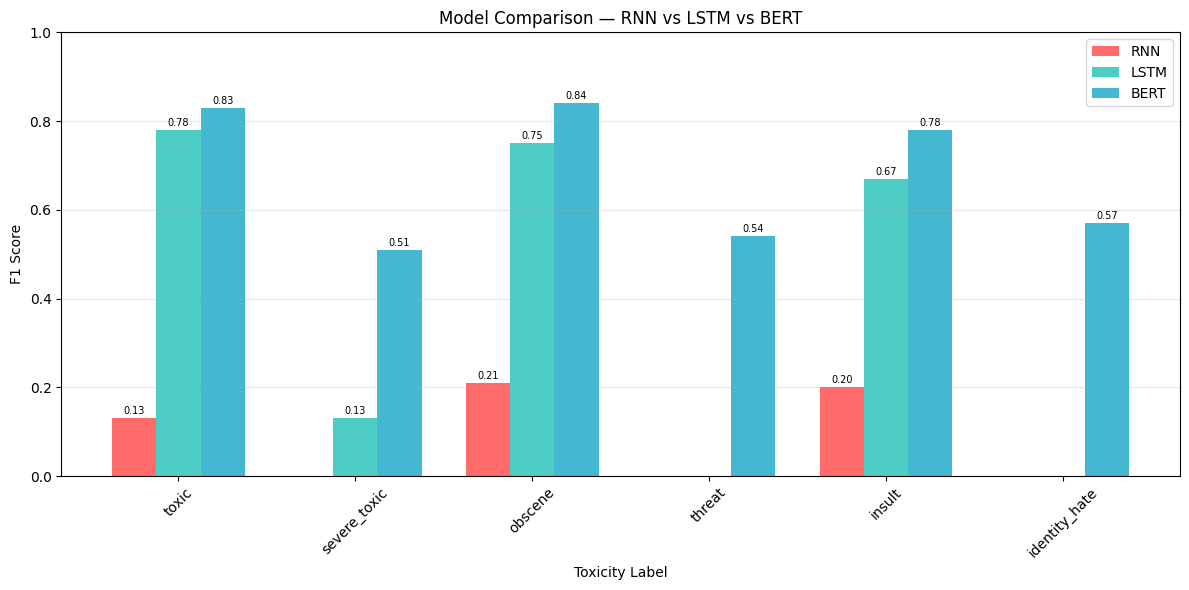

Chart saved ✅


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# F1 scores for all models
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

rnn_f1    = [0.13, 0.00, 0.21, 0.00, 0.20, 0.00]
lstm_f1   = [0.78, 0.13, 0.75, 0.00, 0.67, 0.00]
bert_f1   = [0.83, 0.51, 0.84, 0.54, 0.78, 0.57]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, rnn_f1,  width, label='RNN',  color='#ff6b6b')
bars2 = ax.bar(x,          lstm_f1, width, label='LSTM', color='#4ecdc4')
bars3 = ax.bar(x + width,  bert_f1, width, label='BERT', color='#45b7d1')

ax.set_xlabel('Toxicity Label')
ax.set_ylabel('F1 Score')
ax.set_title('Model Comparison — RNN vs LSTM vs BERT')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MyCommentToxicity/model_comparison.png')
plt.show()
print("Chart saved ✅")

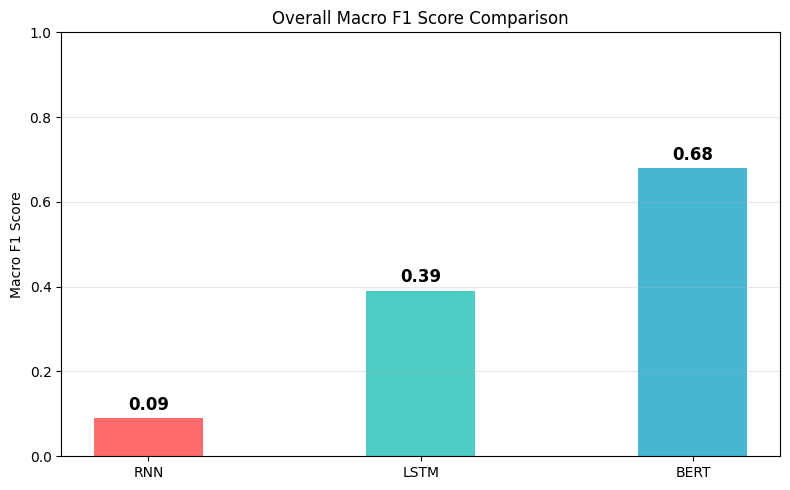

Summary chart saved ✅


In [36]:
models = ['RNN', 'LSTM', 'BERT']
macro_f1 = [0.09, 0.39, 0.68]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, macro_f1, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.4)
plt.title('Overall Macro F1 Score Comparison')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, macro_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MyCommentToxicity/macro_f1_comparison.png')
plt.show()
print("Summary chart saved ✅")